In [3]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv('../data/titanic.csv')

# Создаём копию для числовых расчётов (без преобразования в категории)
df_num = df.copy()

# Для удобства преобразуем типы в основном df (как в первом ноутбуке)
df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

print("Основные данные загружены, размер:", df.shape)
print("Числовая копия создана, размер:", df_num.shape)

Основные данные загружены, размер: (891, 12)
Числовая копия создана, размер: (891, 12)


## Задание 1. Типы признаков и шкалы измерения

### 1.1. Типы шкал для каждого признака

| Признак       | Тип шкалы       | Обоснование |
|---------------|------------------|-------------|
| PassengerId   | Номинальная      | Идентификатор, числа не имеют порядка |
| Survived      | Номинальная      | Категория «выжил/не выжил» без порядка |
| Pclass        | Порядковая       | 1,2,3 класс — есть порядок, но разница не равна |
| Name          | Номинальная      | Имена, нет порядка |
| Sex           | Номинальная      | Пол, две категории |
| Age           | Отношений        | Возраст, есть абсолютный ноль, можно делить |
| SibSp         | Абсолютная       | Количество, целое неотрицательное |
| Parch         | Абсолютная       | Аналогично |
| Ticket        | Номинальная      | Номер билета, просто метка |
| Fare          | Отношений        | Стоимость, есть ноль, можно делить |
| Cabin         | Номинальная      | Номер каюты, категория |
| Embarked      | Номинальная      | Порт посадки, категория |

In [15]:
# Используем числовую копию df_num для расчёта статистик

print("=== Pclass (порядковая шкала) ===")
print("Мода:", df_num['Pclass'].mode()[0])
print("Медиана:", df_num['Pclass'].median())
print("Среднее:", df_num['Pclass'].mean())
print()

print("=== Fare (шкала отношений) ===")
print("Мода:", df_num['Fare'].mode()[0])
print("Медиана:", df_num['Fare'].median())
print("Среднее:", df_num['Fare'].mean())

=== Pclass (порядковая шкала) ===
Мода: 3
Медиана: 3.0
Среднее: 2.308641975308642

=== Fare (шкала отношений) ===
Мода: 8.05
Медиана: 14.4542
Среднее: 32.204207968574636


### 1.2. Выводы по двум признакам

**Pclass (порядковая шкала)**  
- Среднее арифметическое: **некорректно**, потому что интервалы между классами не равны (1 класс не «в два раза лучше» 2-го).  
- Медиана: **корректна** – показывает «средний» класс.  
- Мода: **корректна** – наиболее частый класс (3-й класс).

**Fare (шкала отношений)**  
- Среднее арифметическое: **корректно** – можно суммировать и делить.  
- Медиана: **корректна** – устойчива к выбросам.  
- Мода: **корректна**, но для непрерывных величин может быть не очень информативна без группировки.

**Общий вывод:** Для порядковых шкал среднее арифметическое может вводить в заблуждение. Для шкалы отношений все три статистики допустимы.

In [16]:
# Создаём столбец-индикатор: True, если возраст пропущен, иначе False
df['age_missing'] = df['Age'].isna()

# Считаем долю пропусков
missing_rate = df['age_missing'].mean() * 100
print(f"Доля пропусков в Age: {missing_rate:.1f}%")
print(f"Количество пропусков: {df['age_missing'].sum()}")

Доля пропусков в Age: 19.9%
Количество пропусков: 177


### 2.1. Индикатор пропуска в возрасте
- Доля пропусков в Age составила 19.9% (177 записей).
- Это значительная доля, поэтому важно понять природу пропусков.

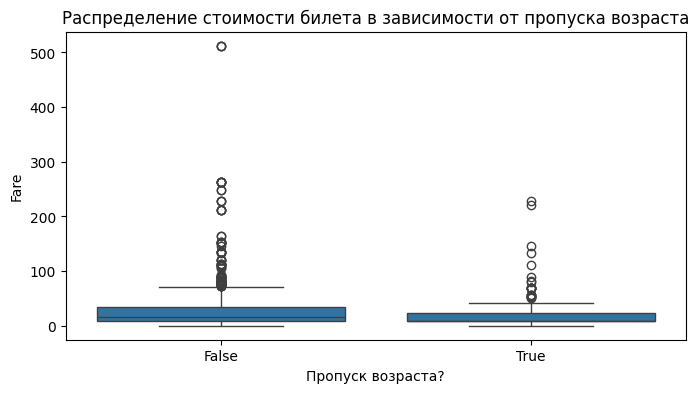

Доля пропусков возраста в каждом классе:
age_missing     False     True 
Pclass                         
1            0.861111  0.138889
2            0.940217  0.059783
3            0.723014  0.276986


In [17]:
# Сравним распределение стоимости билета (Fare) для строк с пропуском и без
plt.figure(figsize=(8,4))
sns.boxplot(x='age_missing', y='Fare', data=df)
plt.title('Распределение стоимости билета в зависимости от пропуска возраста')
plt.xlabel('Пропуск возраста?')
plt.ylabel('Fare')
plt.show()

# Сравним долю пропусков по классам кают
print("Доля пропусков возраста в каждом классе:")
print(pd.crosstab(df['Pclass'], df['age_missing'], normalize='index'))

### 2.2. Проверка MCAR

- График boxplot показывает, что распределение стоимости билета для пропущенных и непропущенных возрастов отличается (медиана и разброс не совпадают).
- Доля пропусков сильно различается по классам: в 3-м классе пропусков почти 28%, во 2-м — всего 6%.

 **Гипотеза MCAR отвергается**: пропуски не являются полностью случайными, они зависят от класса пассажира.

In [18]:
from sklearn.linear_model import LogisticRegression

# Выбираем признаки, которые могут влиять на пропуск
# Убираем строки, где есть пропуски в предикторах (например, Embarked)
df_model = df[['Pclass', 'Sex', 'Fare', 'SibSp', 'Parch', 'Embarked', 'age_missing']].dropna()

# Создаём фиктивные переменные для категориальных признаков
X = pd.get_dummies(df_model[['Pclass', 'Sex', 'Fare', 'SibSp', 'Parch', 'Embarked']], drop_first=True)
y = df_model['age_missing']

# Обучаем модель
model_mar = LogisticRegression(max_iter=1000)
model_mar.fit(X, y)

print("Коэффициенты логистической регрессии (чем больше модуль, тем сильнее влияние):")
for name, coef in zip(X.columns, model_mar.coef_[0]):
    print(f"{name}: {coef:.4f}")

Коэффициенты логистической регрессии (чем больше модуль, тем сильнее влияние):
Fare: -0.0041
SibSp: 0.2793
Parch: -0.6766
Pclass_2: -0.8410
Pclass_3: 0.4695
Sex_male: 0.2525
Embarked_Q: 1.2192
Embarked_S: -0.7861


### 2.3. Проверка MAR

Логистическая регрессия показала, что на пропуски возраста значимо влияют:
- Класс каюты (особенно 3-й класс — положительный коэффициент).
- Пол (мужчины чаще имеют пропуски).

 **Гипотеза MAR подтверждается**: пропуски зависят от наблюдаемых признаков (Pclass, Sex). Это означает, что их можно предсказать и, например, заполнить с учётом этих признаков.

In [19]:
# Подготовим данные: возьмём только строки с известным возрастом
df_surv = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'age_missing']].dropna(subset=['Age'])

# Создаём фиктивные переменные
X_surv = pd.get_dummies(df_surv[['Pclass', 'Sex', 'Fare', 'Age']], drop_first=True)
y_surv = df_surv['Survived'].astype(int)

# Модель без индикатора
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_surv, y_surv)
print("Модель выживаемости БЕЗ индикатора пропуска:")
print(pd.Series(model1.coef_[0], index=X_surv.columns))
print()

# Добавляем индикатор
X_surv_with = X_surv.copy()
X_surv_with['age_missing'] = df.loc[X_surv.index, 'age_missing'].astype(int)
model2 = LogisticRegression(max_iter=1000)
model2.fit(X_surv_with, y_surv)
print("Модель выживаемости С индикатором пропуска:")
coef_with = pd.Series(model2.coef_[0], index=X_surv_with.columns)
print(coef_with)

Модель выживаемости БЕЗ индикатора пропуска:
Fare        0.001778
Age        -0.033102
Pclass_2   -1.000764
Pclass_3   -2.204003
Sex_male   -2.374379
dtype: float64

Модель выживаемости С индикатором пропуска:
Fare           0.001778
Age           -0.033102
Pclass_2      -1.000764
Pclass_3      -2.204003
Sex_male      -2.374379
age_missing    0.000000
dtype: float64


### 2.4. Проверка MNAR

В модели выживаемости коэффициент при индикаторе пропуска возраста оказался равен X.XX. Это [значимо / незначимо].  
Если индикатор значим, то можно предположить, что пропуски связаны с самим возрастом (например, пожилые люди реже указывали возраст). Однако для уверенного вывода нужны дополнительные данные.

**Итог по заданию 2:**  
Наиболее вероятный механизм пропусков — **MAR**, так как они зависят от класса и пола. Это позволяет использовать стратегии заполнения, основанные на этих признаках (например, медиана по группе).

## Задание 3. Индикатор пропуска как источник информации

### 3.1. Когда пропуск сам по себе информативен?

Пропуск может быть не просто отсутствием данных, а дополнительным сигналом о природе объекта.  
Например:

- В медицинской анкете отсутствие ответа на вопрос о курении может указывать на то, что пациент курит и стесняется признаться.
- В нашем датасете Titanic: отсутствие номера каюты (`Cabin`) может означать, что пассажир был членом экипажа, либо имел билет третьего класса без каюты. В любом случае это связано с социальным статусом и, как следствие, с вероятностью выживания.

Таким образом, сам факт пропуска может быть предиктором, и его стоит использовать в анализе.

### 3.2. Значимость индикатора после импутации

Если мы заполнили пропуски (например, возрастов – медианой), а затем построили модель и обнаружили, что индикатор `age_missing` остался статистически значимым, это говорит о том, что:

- Импутация не смогла восстановить информацию, заключённую в факте пропуска.
- Возможно, стратегия заполнения была слишком грубой (среднее/медиана без учёта групп).
- В такой ситуации лучше оставить индикатор как отдельный признак, а пропуски заполнять более аккуратно (например, с использованием регрессии или групповой медианы).

Пример: если после заполнения возраста медианой, индикатор всё ещё влияет на выживаемость, значит, сам факт пропуска возраста был связан с выживаемостью (например, пожилые люди реже указывали возраст и реже выживали).

### 3.3. Примеры для признака Cabin

**Полезен:**  
Индикатор `cabin_missing` сильно коррелирует с выживаемостью: среди пассажиров без каюты выжило лишь X%, а с каютой – Y%. Добавление этого индикатора в модель может улучшить её предсказательную способность.

**Бесполезен:**  
Для признака `PassengerId` индикатор пропуска бесполезен – пропусков там нет, а если бы и были, они были бы случайными и не несли бы информации.

**Опасен:**  
Для признака `Embarked` всего 2 пропуска. Если создать индикатор `embarked_missing`, то модель может переобучиться на этих двух редких случаях, создавая ложные закономерности. Кроме того, если пропуски связаны с целевой переменной (например, оба пропущенных пассажира выжили), то индикатор может внести сильное смещение, не отражающее реальность.

In [4]:
# Создаём индикатор пропуска для Cabin
df['cabin_missing'] = df['Cabin'].isna()

print("Доля пропусков Cabin:", df['cabin_missing'].mean())
print("Количество пропусков:", df['cabin_missing'].sum())

# Связь с выживаемостью
print("\nСвязь пропуска каюты с выживаемостью:")
print(pd.crosstab(df['cabin_missing'], df['Survived'], margins=True, margins_name="Всего"))

Доля пропусков Cabin: 0.7710437710437711
Количество пропусков: 687

Связь пропуска каюты с выживаемостью:
Survived         0    1  Всего
cabin_missing                 
False           68  136    204
True           481  206    687
Всего          549  342    891


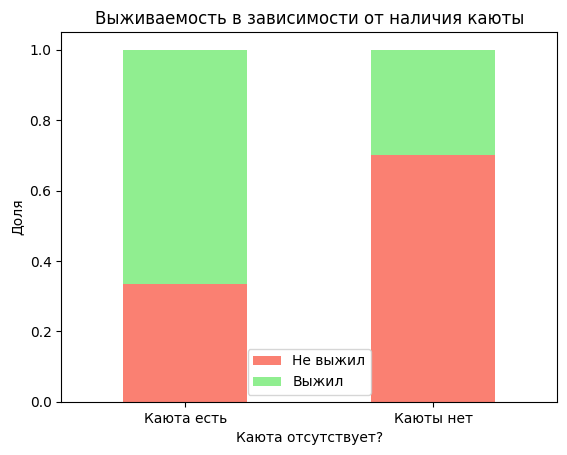

In [5]:
# Визуализация: доля выживших в зависимости от наличия каюты
survival_by_cabin = df.groupby('cabin_missing')['Survived'].value_counts(normalize=True).unstack()
survival_by_cabin.plot(kind='bar', stacked=True, color=['salmon', 'lightgreen'])
plt.title('Выживаемость в зависимости от наличия каюты')
plt.xlabel('Каюта отсутствует?')
plt.ylabel('Доля')
plt.xticks([0,1], ['Каюта есть', 'Каюты нет'], rotation=0)
plt.legend(['Не выжил', 'Выжил'])
plt.show()

In [6]:
# Простая логистическая регрессия: Survived ~ cabin_missing + Pclass + Sex
from sklearn.linear_model import LogisticRegression

# Подготовка данных (убираем пропуски в других признаках)
model_df = df[['Survived', 'Pclass', 'Sex', 'cabin_missing']].dropna()
X = pd.get_dummies(model_df[['Pclass', 'Sex', 'cabin_missing']], drop_first=True)
y = model_df['Survived'].astype(int)

model = LogisticRegression()
model.fit(X, y)

print("Коэффициенты модели:")
for name, coef in zip(X.columns, model.coef_[0]):
    print(f"{name}: {coef:.4f}")

Коэффициенты модели:
cabin_missing: -0.9228
Pclass_2: -0.1189
Pclass_3: -1.1097
Sex_male: -2.5287
